In [2]:
import sqlite3
import pandas as pd
import numpy as np
from pathlib import Path
from scipy import stats

In [3]:
BASE_DIR = Path("/home/agrupa-lab/agrupa")
DB_PATH = BASE_DIR / "agrupa.sqlite"

# Load SADCAT scores
scores_df = pd.read_csv(
    "/home/agrupa-lab/agrupa/IE_capstones/Omar/outputs/sadcat_scores_llava.csv"
)
print(f"Total scored artworks: {len(scores_df)}")
scores_df.head()

Total scored artworks: 6266


,cat_no,titulo,autor,is_fauna,is_religious,century,warmth_score,competence_score,warmth_coverage,competence_coverage,global_coverage
0,P000002,El juicio de Paris,"Albani, Francesco",1,0,17th c.,0.529412,0.764706,3.926097,3.926097,NaN
1,P000006,Sagrada Familia y el cardenal Fernando de Medici,"Allori, Alessandro",1,1,16th c.,0.708333,1.000000,5.000000,3.125000,NaN
2,P000013,Rendición de Sevilla al rey san Fernando,"Flipart, Charles-Joseph",1,0,18th c.,0.400000,1.000000,5.387931,1.939655,NaN
3,P000014,"María Isabel de Borbón y Sajonia, infanta de N...","Ruta, Clemente",1,0,18th c.,0.307692,0.357143,7.492795,8.069164,NaN
4,P000015,La Anunciación,"Angelico, Fra",1,1,15th c.,0.625000,0.578947,4.188482,4.973822,NaN


In [4]:
conn = sqlite3.connect(DB_PATH)

artwork_tags = pd.read_sql("""
    SELECT at.cat_no, it.tag_id, it.name, it.slug
    FROM artwork_tag at
    INNER JOIN icon_tag it ON at.tag_id = it.tag_id
""", conn)
conn.close()

print(f"Total artwork-tag pairs: {len(artwork_tags)}")
artwork_tags.head()

Total artwork-tag pairs: 40221


,cat_no,tag_id,name,slug
0,P000002,133,Pavo,fauna/aves/pavo
1,P000002,237,Personas,personas
2,P000002,275,Desnudo femenino,temas/figura-humana/desnudo/desnudo-femenino
3,P000002,276,Desnudo infantil,temas/figura-humana/desnudo/desnudo-infantil
4,P000002,277,Desnudo masculino,temas/figura-humana/desnudo/desnudo-masculino


In [5]:
# Elite tag IDs
elite_ids = [402, 403, 406, 407, 408, 409]

# Non-elite tag IDs  
nonelite_ids = [358, 359, 360, 361, 364, 369, 370, 371, 372, 373, 376, 377, 380]

# Get artworks for each group
elite_cats = artwork_tags[artwork_tags['tag_id'].isin(elite_ids)]['cat_no'].unique()
nonelite_cats = artwork_tags[artwork_tags['tag_id'].isin(nonelite_ids)]['cat_no'].unique()

print(f"Elite artworks: {len(elite_cats)}")
print(f"Non-elite artworks: {len(nonelite_cats)}")

# Merge with scores
elite_scores = scores_df[scores_df['cat_no'].isin(elite_cats)].copy()
nonelite_scores = scores_df[scores_df['cat_no'].isin(nonelite_cats)].copy()

print(f"\nElite artworks with scores: {len(elite_scores)}")
print(f"Non-elite artworks with scores: {len(nonelite_scores)}")

Elite artworks: 2240
Non-elite artworks: 248

Elite artworks with scores: 998
Non-elite artworks with scores: 155


In [6]:
elite_comp = elite_scores['competence_score'].dropna()
nonelite_comp = nonelite_scores['competence_score'].dropna()

print("=== H1a: Elite vs Non-Elite Competence ===")
print(f"\nElite competence:    mean={elite_comp.mean():.3f}, std={elite_comp.std():.3f}, n={len(elite_comp)}")
print(f"Non-elite competence: mean={nonelite_comp.mean():.3f}, std={nonelite_comp.std():.3f}, n={len(nonelite_comp)}")

t_stat, p_value = stats.ttest_ind(elite_comp, nonelite_comp)
print(f"\nt-test: t={t_stat:.3f}, p={p_value:.4f}")
if p_value < 0.05:
    print("Result: SIGNIFICANT difference ✓")
    if elite_comp.mean() > nonelite_comp.mean():
        print("Direction: Elite figures have HIGHER competence → H1a SUPPORTED")
    else:
        print("Direction: Elite figures have LOWER competence → H1a NOT SUPPORTED")
else:
    print("Result: No significant difference → H1a NOT SUPPORTED")

=== H1a: Elite vs Non-Elite Competence ===

Elite competence:    mean=0.806, std=0.225, n=997
Non-elite competence: mean=0.589, std=0.257, n=155

t-test: t=10.962, p=0.0000
Result: SIGNIFICANT difference ✓
Direction: Elite figures have HIGHER competence → H1a SUPPORTED


In [7]:
elite_warm = elite_scores['warmth_score'].dropna()
nonelite_warm = nonelite_scores['warmth_score'].dropna()

print("=== H1b: Non-Elite Higher Warmth ===")
print(f"\nElite warmth:     mean={elite_warm.mean():.3f}, std={elite_warm.std():.3f}")
print(f"Non-elite warmth: mean={nonelite_warm.mean():.3f}, std={nonelite_warm.std():.3f}")

t_stat, p_value = stats.ttest_ind(nonelite_warm, elite_warm)
print(f"\nt-test: t={t_stat:.3f}, p={p_value:.4f}")
if p_value < 0.05:
    print("Result: SIGNIFICANT difference ✓")
    if nonelite_warm.mean() > elite_warm.mean():
        print("Direction: Non-elite has HIGHER warmth → H1b SUPPORTED")
    else:
        print("Direction: Non-elite has LOWER warmth → H1b NOT SUPPORTED")
else:
    print("Result: No significant difference → H1b NOT SUPPORTED")

=== H1b: Non-Elite Higher Warmth ===

Elite warmth:     mean=0.331, std=0.240
Non-elite warmth: mean=0.477, std=0.197

t-test: t=7.198, p=0.0000
Result: SIGNIFICANT difference ✓
Direction: Non-elite has HIGHER warmth → H1b SUPPORTED


In [8]:
# Predatory tag IDs
predatory_ids = [206, 205, 208, 202, 216, 204, 194]

# Domesticated tag IDs
domesticated_ids = [217, 178, 215, 179, 176, 173, 182, 192]

predatory_cats = artwork_tags[artwork_tags['tag_id'].isin(predatory_ids)]['cat_no'].unique()
domesticated_cats = artwork_tags[artwork_tags['tag_id'].isin(domesticated_ids)]['cat_no'].unique()

print(f"Predatory artworks: {len(predatory_cats)}")
print(f"Domesticated artworks: {len(domesticated_cats)}")

predatory_scores = scores_df[scores_df['cat_no'].isin(predatory_cats)].copy()
domesticated_scores = scores_df[scores_df['cat_no'].isin(domesticated_cats)].copy()

print(f"\nPredatory with scores: {len(predatory_scores)}")
print(f"Domesticated with scores: {len(domesticated_scores)}")

Predatory artworks: 186
Domesticated artworks: 1675

Predatory with scores: 156
Domesticated with scores: 1357


In [9]:
pred_comp = predatory_scores['competence_score'].dropna()
dom_comp = domesticated_scores['competence_score'].dropna()
pred_warm = predatory_scores['warmth_score'].dropna()
dom_warm = domesticated_scores['warmth_score'].dropna()

print("=== H2a: Predatory vs Domesticated ===")
print(f"\nPredatory:    competence={pred_comp.mean():.3f}, warmth={pred_warm.mean():.3f}")
print(f"Domesticated: competence={dom_comp.mean():.3f}, warmth={dom_warm.mean():.3f}")

t_comp, p_comp = stats.ttest_ind(pred_comp, dom_comp)
t_warm, p_warm = stats.ttest_ind(pred_warm, dom_warm)

print(f"\nCompetence t-test: t={t_comp:.3f}, p={p_comp:.4f}")
print(f"Warmth t-test:     t={t_warm:.3f}, p={p_warm:.4f}")

if p_comp < 0.05 and pred_comp.mean() > dom_comp.mean():
    print("\nCompetence: Predatory HIGHER → H2a competence SUPPORTED")
else:
    print("\nCompetence: H2a competence NOT SUPPORTED")

if p_warm < 0.05 and pred_warm.mean() < dom_warm.mean():
    print("Warmth: Predatory LOWER → H2a warmth SUPPORTED")
else:
    print("Warmth: H2a warmth NOT SUPPORTED")

=== H2a: Predatory vs Domesticated ===

Predatory:    competence=0.751, warmth=0.414
Domesticated: competence=0.702, warmth=0.442

Competence t-test: t=2.349, p=0.0190
Warmth t-test:     t=-1.432, p=0.1524

Competence: Predatory HIGHER → H2a competence SUPPORTED
Warmth: H2a warmth NOT SUPPORTED


In [10]:
# H2b: Domesticated animals cluster in high warmth, moderate/low competence
print("=== H2b: Domesticated Animals Warmth-Competence Position ===")

dom_warm_mean = domesticated_scores['warmth_score'].mean()
dom_comp_mean = domesticated_scores['competence_score'].mean()

print(f"\nDomesticated animals:")
print(f"  Mean Warmth:     {dom_warm_mean:.3f}")
print(f"  Mean Competence: {dom_comp_mean:.3f}")

# High warmth = above overall mean warmth
overall_warm_mean = scores_df['warmth_score'].mean()
overall_comp_mean = scores_df['competence_score'].mean()

print(f"\nOverall dataset means:")
print(f"  Mean Warmth:     {overall_warm_mean:.3f}")
print(f"  Mean Competence: {overall_comp_mean:.3f}")

high_warmth = dom_warm_mean > overall_warm_mean
low_comp = dom_comp_mean < overall_comp_mean

print(f"\nDomesticated warmth above overall mean: {high_warmth}")
print(f"Domesticated competence below overall mean: {low_comp}")

if high_warmth and low_comp:
    print("\n→ H2b SUPPORTED: Domesticated animals cluster in high warmth, low competence")
elif high_warmth and not low_comp:
    print("\n→ H2b PARTIALLY SUPPORTED: High warmth but competence not low")
else:
    print("\n→ H2b NOT SUPPORTED")

=== H2b: Domesticated Animals Warmth-Competence Position ===

Domesticated animals:
  Mean Warmth:     0.442
  Mean Competence: 0.702

Overall dataset means:
  Mean Warmth:     0.369
  Mean Competence: 0.732

Domesticated warmth above overall mean: True
Domesticated competence below overall mean: True

→ H2b SUPPORTED: Domesticated animals cluster in high warmth, low competence


In [11]:
summary = pd.DataFrame({
    'Group': ['Elite', 'Non-Elite', 'Predatory', 'Domesticated', 'Overall'],
    'N': [
        len(elite_scores), 
        len(nonelite_scores), 
        len(predatory_scores), 
        len(domesticated_scores),
        len(scores_df)
    ],
    'Mean Warmth': [
        elite_scores['warmth_score'].mean(),
        nonelite_scores['warmth_score'].mean(),
        predatory_scores['warmth_score'].mean(),
        domesticated_scores['warmth_score'].mean(),
        scores_df['warmth_score'].mean()
    ],
    'Warmth Std': [
        elite_scores['warmth_score'].std(),
        nonelite_scores['warmth_score'].std(),
        predatory_scores['warmth_score'].std(),
        domesticated_scores['warmth_score'].std(),
        scores_df['warmth_score'].std()
    ],
    'Mean Competence': [
        elite_scores['competence_score'].mean(),
        nonelite_scores['competence_score'].mean(),
        predatory_scores['competence_score'].mean(),
        domesticated_scores['competence_score'].mean(),
        scores_df['competence_score'].mean()
    ],
    'Competence Std': [
        elite_scores['competence_score'].std(),
        nonelite_scores['competence_score'].std(),
        predatory_scores['competence_score'].std(),
        domesticated_scores['competence_score'].std(),
        scores_df['competence_score'].std()
    ]
}).round(3)

print(summary.to_string(index=False))

       Group    N  Mean Warmth  Warmth Std  Mean Competence  Competence Std
       Elite  998        0.331       0.240            0.806           0.225
   Non-Elite  155        0.477       0.197            0.589           0.257
   Predatory  156        0.414       0.242            0.751           0.221
Domesticated 1357        0.442       0.230            0.702           0.249
     Overall 6266        0.369       0.245            0.732           0.255


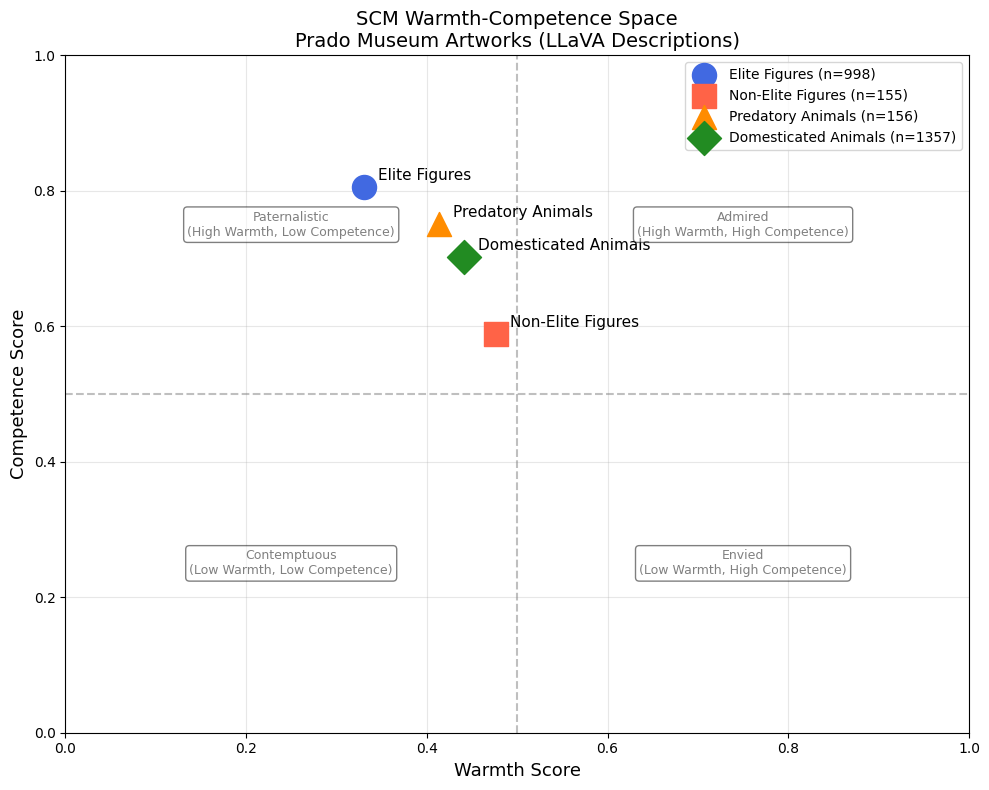

Plot saved!


In [12]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(1, 1, figsize=(10, 8))

groups = {
    'Elite Figures':        (elite_scores['warmth_score'].mean(), elite_scores['competence_score'].mean(), 'royalblue', 'o', len(elite_scores)),
    'Non-Elite Figures':    (nonelite_scores['warmth_score'].mean(), nonelite_scores['competence_score'].mean(), 'tomato', 's', len(nonelite_scores)),
    'Predatory Animals':    (predatory_scores['warmth_score'].mean(), predatory_scores['competence_score'].mean(), 'darkorange', '^', len(predatory_scores)),
    'Domesticated Animals': (domesticated_scores['warmth_score'].mean(), domesticated_scores['competence_score'].mean(), 'forestgreen', 'D', len(domesticated_scores)),
}

for name, (warmth, competence, color, marker, n) in groups.items():
    ax.scatter(warmth, competence, c=color, marker=marker, s=300, zorder=5, label=f'{name} (n={n})')
    ax.annotate(name, (warmth, competence),
                textcoords="offset points", xytext=(10, 5), fontsize=11)

# Quadrant lines at midpoint (0.5)
ax.axvline(x=0.5, color='gray', linestyle='--', alpha=0.5)
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)

# Quadrant labels repositioned to center of each quadrant
ax.text(0.25, 0.75, 'Paternalistic\n(High Warmth, Low Competence)',
        fontsize=9, ha='center', va='center', color='gray',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.5))
ax.text(0.75, 0.75, 'Admired\n(High Warmth, High Competence)',
        fontsize=9, ha='center', va='center', color='gray',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.5))
ax.text(0.25, 0.25, 'Contemptuous\n(Low Warmth, Low Competence)',
        fontsize=9, ha='center', va='center', color='gray',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.5))
ax.text(0.75, 0.25, 'Envied\n(Low Warmth, High Competence)',
        fontsize=9, ha='center', va='center', color='gray',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.5))

# Set scale from 0 to 1
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

ax.set_xlabel('Warmth Score', fontsize=13)
ax.set_ylabel('Competence Score', fontsize=13)
ax.set_title('SCM Warmth-Competence Space\nPrado Museum Artworks (LLaVA Descriptions)', fontsize=14)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/home/agrupa-lab/agrupa/IE_capstones/Omar/outputs/scm_quadrant.png', dpi=300, bbox_inches='tight')
plt.show()
print("Plot saved!")

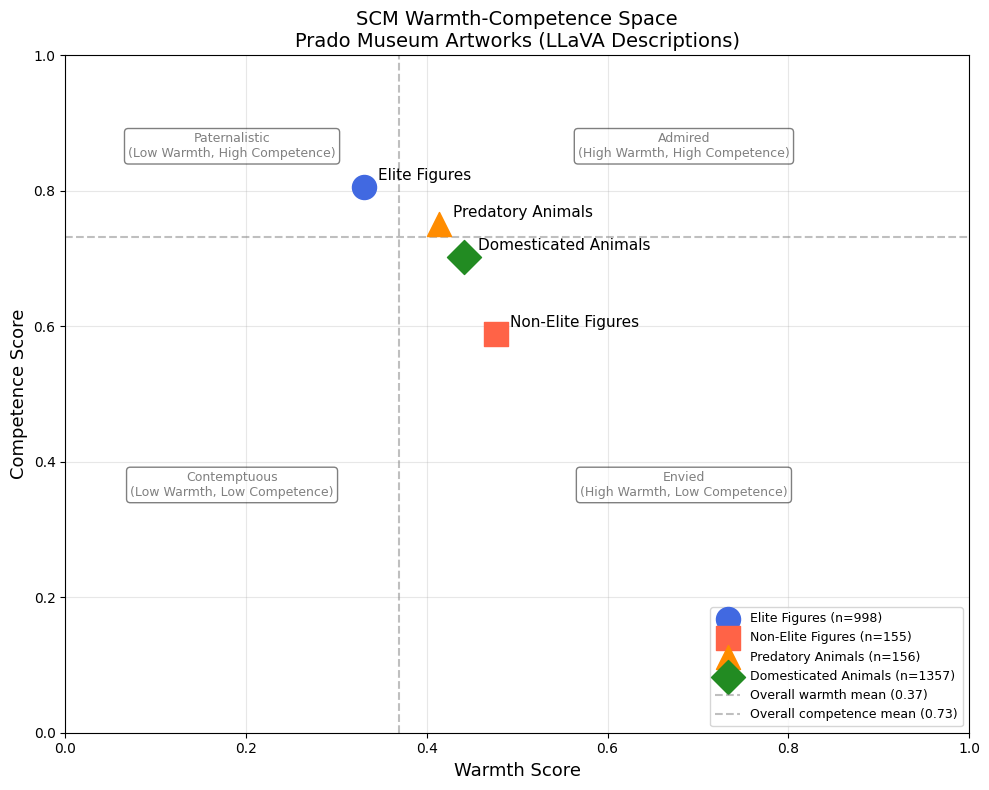

Plot saved!


In [13]:
fig, ax = plt.subplots(1, 1, figsize=(10, 8))

groups = {
    'Elite Figures':        (elite_scores['warmth_score'].mean(), elite_scores['competence_score'].mean(), 'royalblue', 'o', len(elite_scores)),
    'Non-Elite Figures':    (nonelite_scores['warmth_score'].mean(), nonelite_scores['competence_score'].mean(), 'tomato', 's', len(nonelite_scores)),
    'Predatory Animals':    (predatory_scores['warmth_score'].mean(), predatory_scores['competence_score'].mean(), 'darkorange', '^', len(predatory_scores)),
    'Domesticated Animals': (domesticated_scores['warmth_score'].mean(), domesticated_scores['competence_score'].mean(), 'forestgreen', 'D', len(domesticated_scores)),
}

for name, (warmth, competence, color, marker, n) in groups.items():
    ax.scatter(warmth, competence, c=color, marker=marker, s=300, zorder=5, label=f'{name} (n={n})')
    ax.annotate(name, (warmth, competence),
                textcoords="offset points", xytext=(10, 5), fontsize=11)

# Quadrant lines at overall dataset means
overall_warmth_mean = scores_df['warmth_score'].mean()
overall_comp_mean = scores_df['competence_score'].mean()

ax.axvline(x=overall_warmth_mean, color='gray', linestyle='--', alpha=0.5, 
           label=f'Overall warmth mean ({overall_warmth_mean:.2f})')
ax.axhline(y=overall_comp_mean, color='gray', linestyle='--', alpha=0.5,
           label=f'Overall competence mean ({overall_comp_mean:.2f})')

# Quadrant labels positioned at center of each quadrant based on means
mid_w_left  = overall_warmth_mean / 2
mid_w_right = overall_warmth_mean + (1 - overall_warmth_mean) / 2
mid_c_top   = overall_comp_mean + (1 - overall_comp_mean) / 2
mid_c_bot   = overall_comp_mean / 2

ax.text(mid_w_left, mid_c_top, 'Paternalistic\n(Low Warmth, High Competence)',
        fontsize=9, ha='center', va='center', color='gray',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.5))
ax.text(mid_w_right, mid_c_top, 'Admired\n(High Warmth, High Competence)',
        fontsize=9, ha='center', va='center', color='gray',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.5))
ax.text(mid_w_left, mid_c_bot, 'Contemptuous\n(Low Warmth, Low Competence)',
        fontsize=9, ha='center', va='center', color='gray',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.5))
ax.text(mid_w_right, mid_c_bot, 'Envied\n(High Warmth, Low Competence)',
        fontsize=9, ha='center', va='center', color='gray',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.5))

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

ax.set_xlabel('Warmth Score', fontsize=13)
ax.set_ylabel('Competence Score', fontsize=13)
ax.set_title('SCM Warmth-Competence Space\nPrado Museum Artworks (LLaVA Descriptions)', fontsize=14)
ax.legend(fontsize=9, loc='lower right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/home/agrupa-lab/agrupa/IE_capstones/Omar/outputs/scm_quadrant_means.png', dpi=300, bbox_inches='tight')
plt.show()
print("Plot saved!")

In [14]:
print(scores_df['century'].value_counts().sort_index())

century
12th c.      21
13th c.       5
14th c.      10
15th c.     178
16th c.     735
17th c.    2511
18th c.     879
19th c.    1615
20th c.     312
Name: count, dtype: int64


In [15]:
# Define century order
century_order = ['12th c.', '13th c.', '14th c.', '15th c.', '16th c.', 
                 '17th c.', '18th c.', '19th c.', '20th c.']

# Filter to centuries with enough data (at least 30 artworks)
century_counts = scores_df['century'].value_counts()
valid_centuries = century_counts[century_counts >= 30].index.tolist()
df_temporal = scores_df[scores_df['century'].isin(valid_centuries)].copy()

# Calculate mean warmth and competence per century
century_stats = df_temporal.groupby('century').agg(
    mean_warmth=('warmth_score', 'mean'),
    std_warmth=('warmth_score', 'std'),
    mean_competence=('competence_score', 'mean'),
    std_competence=('competence_score', 'std'),
    n=('cat_no', 'count')
).reindex([c for c in century_order if c in valid_centuries]).reset_index()

print(century_stats.to_string(index=False))

century  mean_warmth  std_warmth  mean_competence  std_competence    n
15th c.     0.423979    0.241810         0.751845        0.252941  178
16th c.     0.400315    0.230855         0.742492        0.257016  735
17th c.     0.371880    0.239238         0.752612        0.237034 2511
18th c.     0.396989    0.224372         0.713361        0.251625  879
19th c.     0.338385    0.264537         0.716471        0.268925 1615
20th c.     0.310475    0.241783         0.647251        0.297108  312


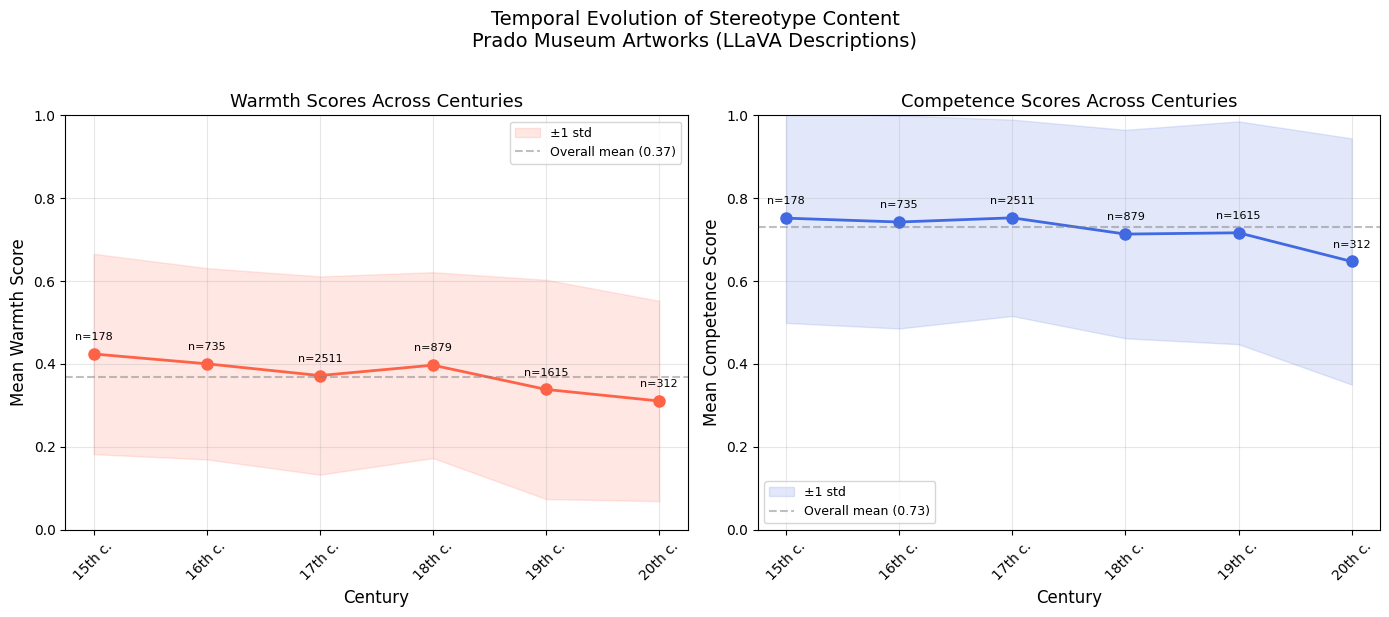

Plot saved!


In [16]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

centuries = century_stats['century']
x = range(len(centuries))

# Plot 1 — Warmth over time
ax1.plot(x, century_stats['mean_warmth'], 'o-', color='tomato', linewidth=2, markersize=8)
ax1.fill_between(x,
    century_stats['mean_warmth'] - century_stats['std_warmth'],
    century_stats['mean_warmth'] + century_stats['std_warmth'],
    alpha=0.15, color='tomato', label='±1 std')
ax1.axhline(y=scores_df['warmth_score'].mean(), color='gray', 
            linestyle='--', alpha=0.5, label=f'Overall mean ({scores_df["warmth_score"].mean():.2f})')
for i, row in century_stats.iterrows():
    ax1.annotate(f'n={row["n"]}', (i, row['mean_warmth']),
                textcoords="offset points", xytext=(0, 10), fontsize=8, ha='center')
ax1.set_xticks(x)
ax1.set_xticklabels(centuries, rotation=45)
ax1.set_ylim(0, 1)
ax1.set_xlabel('Century', fontsize=12)
ax1.set_ylabel('Mean Warmth Score', fontsize=12)
ax1.set_title('Warmth Scores Across Centuries', fontsize=13)
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# Plot 2 — Competence over time
ax2.plot(x, century_stats['mean_competence'], 'o-', color='royalblue', linewidth=2, markersize=8)
ax2.fill_between(x,
    century_stats['mean_competence'] - century_stats['std_competence'],
    century_stats['mean_competence'] + century_stats['std_competence'],
    alpha=0.15, color='royalblue', label='±1 std')
ax2.axhline(y=scores_df['competence_score'].mean(), color='gray',
            linestyle='--', alpha=0.5, label=f'Overall mean ({scores_df["competence_score"].mean():.2f})')
for i, row in century_stats.iterrows():
    ax2.annotate(f'n={row["n"]}', (i, row['mean_competence']),
                textcoords="offset points", xytext=(0, 10), fontsize=8, ha='center')
ax2.set_xticks(x)
ax2.set_xticklabels(centuries, rotation=45)
ax2.set_ylim(0, 1)
ax2.set_xlabel('Century', fontsize=12)
ax2.set_ylabel('Mean Competence Score', fontsize=12)
ax2.set_title('Competence Scores Across Centuries', fontsize=13)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.suptitle('Temporal Evolution of Stereotype Content\nPrado Museum Artworks (LLaVA Descriptions)', 
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('/home/agrupa-lab/agrupa/IE_capstones/Omar/outputs/temporal_analysis.png', 
            dpi=300, bbox_inches='tight')
plt.show()
print("Plot saved!")

In [17]:
from scipy.stats import spearmanr

# Convert centuries to numbers for correlation
century_map = {
    '15th c.': 15, '16th c.': 16, '17th c.': 17,
    '18th c.': 18, '19th c.': 19, '20th c.': 20
}

df_temporal['century_num'] = df_temporal['century'].map(century_map)

# Spearman correlation for warmth
corr_w, p_w = spearmanr(df_temporal['century_num'], df_temporal['warmth_score'].fillna(0))
corr_c, p_c = spearmanr(df_temporal['century_num'], df_temporal['competence_score'].fillna(0))

print("=== Temporal Trend Analysis ===")
print(f"\nWarmth vs Century:     r={corr_w:.3f}, p={p_w:.4f}")
print(f"Competence vs Century: r={corr_c:.3f}, p={p_c:.4f}")

if p_w < 0.05:
    direction = "decreasing" if corr_w < 0 else "increasing"
    print(f"\nWarmth shows significant {direction} trend over time ✓")
else:
    print("\nWarmth trend not statistically significant")

if p_c < 0.05:
    direction = "decreasing" if corr_c < 0 else "increasing"
    print(f"Competence shows significant {direction} trend over time ✓")
else:
    print("Competence trend not statistically significant")

=== Temporal Trend Analysis ===

Warmth vs Century:     r=-0.086, p=0.0000
Competence vs Century: r=-0.076, p=0.0000

Warmth shows significant decreasing trend over time ✓
Competence shows significant decreasing trend over time ✓


In [18]:
# Elite subcategory tag IDs
elite_subcategories = {
    'Retrato Real':        406,
    'Retrato Emperador':   407,
    'Retrato Aristocrático': 408,
    'Retrato Eclesiástico': 409,
    'Retrato Militar':     403,
    'Retrato Ecuestre':    402
}

for name, tag_id in elite_subcategories.items():
    cats = artwork_tags[artwork_tags['tag_id'] == tag_id]['cat_no'].unique()
    scored = scores_df[scores_df['cat_no'].isin(cats)]
    print(f"{name}: {len(cats)} artworks, {len(scored)} with scores")

Retrato Real: 1174 artworks, 578 with scores
Retrato Emperador: 54 artworks, 5 with scores
Retrato Aristocrático: 679 artworks, 279 with scores
Retrato Eclesiástico: 276 artworks, 82 with scores
Retrato Militar: 154 artworks, 71 with scores
Retrato Ecuestre: 113 artworks, 43 with scores


In [19]:
# Define elite subcategories (dropping Emperador - only 5 artworks)
elite_subcategories = {
    'Royal':          406,
    'Aristocratic':   408,
    'Ecclesiastical': 409,
    'Military':       403,
    'Equestrian':     402
}

# Get scores for each subcategory
subcat_scores = {}
for name, tag_id in elite_subcategories.items():
    cats = artwork_tags[artwork_tags['tag_id'] == tag_id]['cat_no'].unique()
    subcat_scores[name] = scores_df[scores_df['cat_no'].isin(cats)].copy()

# Summary table
subcat_summary = pd.DataFrame({
    'Subcategory': list(subcat_scores.keys()),
    'N': [len(df) for df in subcat_scores.values()],
    'Mean Warmth': [df['warmth_score'].mean() for df in subcat_scores.values()],
    'Warmth Std':  [df['warmth_score'].std() for df in subcat_scores.values()],
    'Mean Competence': [df['competence_score'].mean() for df in subcat_scores.values()],
    'Competence Std':  [df['competence_score'].std() for df in subcat_scores.values()]
}).round(3).sort_values('Mean Competence', ascending=False)

print(subcat_summary.to_string(index=False))

   Subcategory   N  Mean Warmth  Warmth Std  Mean Competence  Competence Std
Ecclesiastical  82        0.374       0.207            0.857           0.169
      Military  71        0.363       0.241            0.850           0.186
    Equestrian  43        0.414       0.188            0.804           0.248
  Aristocratic 279        0.286       0.257            0.802           0.240
         Royal 578        0.347       0.234            0.801           0.227


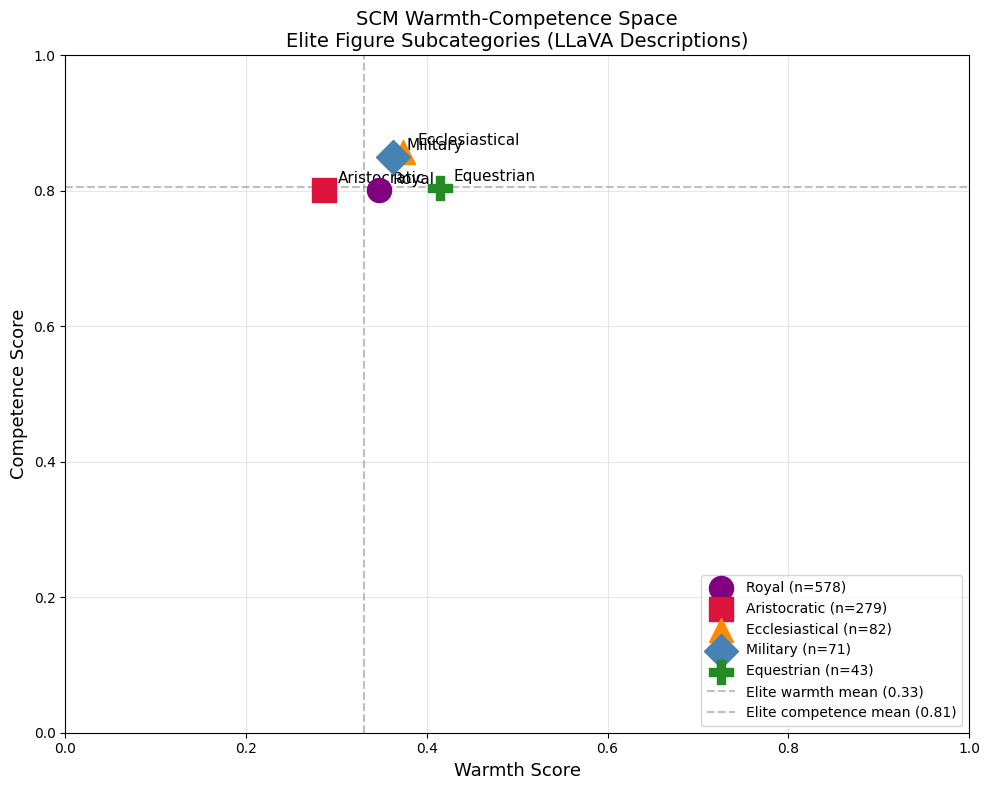

Plot saved!


In [20]:
fig, ax = plt.subplots(figsize=(10, 8))

colors = ['purple', 'crimson', 'darkorange', 'steelblue', 'forestgreen']
markers = ['o', 's', '^', 'D', 'P']

for (name, df), color, marker in zip(subcat_scores.items(), colors, markers):
    warmth = df['warmth_score'].mean()
    competence = df['competence_score'].mean()
    n = len(df)
    ax.scatter(warmth, competence, c=color, marker=marker, 
               s=300, zorder=5, label=f'{name} (n={n})')
    ax.annotate(name, (warmth, competence),
                textcoords="offset points", xytext=(10, 5), fontsize=11)

# Quadrant lines at overall elite means
elite_warmth_mean = elite_scores['warmth_score'].mean()
elite_comp_mean = elite_scores['competence_score'].mean()

ax.axvline(x=elite_warmth_mean, color='gray', linestyle='--', alpha=0.5,
           label=f'Elite warmth mean ({elite_warmth_mean:.2f})')
ax.axhline(y=elite_comp_mean, color='gray', linestyle='--', alpha=0.5,
           label=f'Elite competence mean ({elite_comp_mean:.2f})')

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xlabel('Warmth Score', fontsize=13)
ax.set_ylabel('Competence Score', fontsize=13)
ax.set_title('SCM Warmth-Competence Space\nElite Figure Subcategories (LLaVA Descriptions)', fontsize=14)
ax.legend(fontsize=10, loc='lower right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/home/agrupa-lab/agrupa/IE_capstones/Omar/outputs/elite_subcategory_scm.png', 
            dpi=300, bbox_inches='tight')
plt.show()
print("Plot saved!")

In [21]:
from scipy.stats import f_oneway, kruskal

# Extract scores for each subcategory
groups_warmth = [df['warmth_score'].dropna().values for df in subcat_scores.values()]
groups_comp = [df['competence_score'].dropna().values for df in subcat_scores.values()]

# Kruskal-Wallis test (non-parametric ANOVA)
kw_warmth, p_warmth = kruskal(*groups_warmth)
kw_comp, p_comp = kruskal(*groups_comp)

print("=== Elite Subcategory Differences ===")
print(f"\nKruskal-Wallis Warmth:     H={kw_warmth:.3f}, p={p_warmth:.4f}")
print(f"Kruskal-Wallis Competence: H={kw_comp:.3f}, p={p_comp:.4f}")

if p_warmth < 0.05:
    print("\nWarmth: SIGNIFICANT differences across elite subcategories ✓")
else:
    print("\nWarmth: No significant differences across elite subcategories")

if p_comp < 0.05:
    print("Competence: SIGNIFICANT differences across elite subcategories ✓")
else:
    print("Competence: No significant differences across elite subcategories")

=== Elite Subcategory Differences ===

Kruskal-Wallis Warmth:     H=18.951, p=0.0008
Kruskal-Wallis Competence: H=5.451, p=0.2440

Warmth: SIGNIFICANT differences across elite subcategories ✓
Competence: No significant differences across elite subcategories


In [22]:
# Define animal subcategories
predatory_subcategories = {
    'Lion':    206,
    'Leopard': 205,
    'Wolf':    208,
    'Tiger':   202,
    'Panther': 216,
    'Fox':     204,
    'Boar':    194
}

domesticated_subcategories = {
    'Dog':    217,
    'Horse':  178,
    'Sheep':  215,
    'Goat':   179,
    'Cow':    176,
    'Ox':     173,
    'Pig':    182,
    'Cat':    192
}

print("=== Predatory Animals ===")
for name, tag_id in predatory_subcategories.items():
    cats = artwork_tags[artwork_tags['tag_id'] == tag_id]['cat_no'].unique()
    scored = scores_df[scores_df['cat_no'].isin(cats)]
    print(f"{name}: {len(cats)} artworks, {len(scored)} with scores")

print("\n=== Domesticated Animals ===")
for name, tag_id in domesticated_subcategories.items():
    cats = artwork_tags[artwork_tags['tag_id'] == tag_id]['cat_no'].unique()
    scored = scores_df[scores_df['cat_no'].isin(cats)]
    print(f"{name}: {len(cats)} artworks, {len(scored)} with scores")

=== Predatory Animals ===
Lion: 119 artworks, 100 with scores
Leopard: 5 artworks, 4 with scores
Wolf: 17 artworks, 14 with scores
Tiger: 12 artworks, 10 with scores
Panther: 2 artworks, 2 with scores
Fox: 24 artworks, 22 with scores
Boar: 31 artworks, 26 with scores

=== Domesticated Animals ===
Dog: 856 artworks, 711 with scores
Horse: 763 artworks, 626 with scores
Sheep: 323 artworks, 268 with scores
Goat: 109 artworks, 95 with scores
Cow: 51 artworks, 46 with scores
Ox: 45 artworks, 30 with scores
Pig: 35 artworks, 31 with scores
Cat: 76 artworks, 59 with scores


In [23]:
# Drop subcategories with too few artworks
predatory_subcategories = {
    'Lion':  206,
    'Wolf':  208,
    'Tiger': 202,
    'Fox':   204,
    'Boar':  194
}

domesticated_subcategories = {
    'Dog':   217,
    'Horse': 178,
    'Sheep': 215,
    'Goat':  179,
    'Cow':   176,
    'Ox':    173,
    'Pig':   182,
    'Cat':   192
}

# Get scores for each subcategory
pred_subcat_scores = {}
for name, tag_id in predatory_subcategories.items():
    cats = artwork_tags[artwork_tags['tag_id'] == tag_id]['cat_no'].unique()
    pred_subcat_scores[name] = scores_df[scores_df['cat_no'].isin(cats)].copy()

dom_subcat_scores = {}
for name, tag_id in domesticated_subcategories.items():
    cats = artwork_tags[artwork_tags['tag_id'] == tag_id]['cat_no'].unique()
    dom_subcat_scores[name] = scores_df[scores_df['cat_no'].isin(cats)].copy()

# Summary table
all_animal_scores = {**pred_subcat_scores, **dom_subcat_scores}
animal_summary = pd.DataFrame({
    'Animal':          list(all_animal_scores.keys()),
    'Type':            ['Predatory']*5 + ['Domesticated']*8,
    'N':               [len(df) for df in all_animal_scores.values()],
    'Mean Warmth':     [df['warmth_score'].mean() for df in all_animal_scores.values()],
    'Warmth Std':      [df['warmth_score'].std() for df in all_animal_scores.values()],
    'Mean Competence': [df['competence_score'].mean() for df in all_animal_scores.values()],
    'Competence Std':  [df['competence_score'].std() for df in all_animal_scores.values()]
}).round(3).sort_values('Mean Competence', ascending=False)

print(animal_summary.to_string(index=False))

Animal         Type   N  Mean Warmth  Warmth Std  Mean Competence  Competence Std
  Lion    Predatory 100        0.419       0.230            0.785           0.194
 Tiger    Predatory  10        0.444       0.196            0.782           0.179
  Boar    Predatory  26        0.486       0.215            0.758           0.238
 Horse Domesticated 626        0.436       0.251            0.736           0.224
   Dog Domesticated 711        0.473       0.204            0.712           0.234
   Pig Domesticated  31        0.442       0.268            0.706           0.222
   Cat Domesticated  59        0.464       0.252            0.698           0.257
    Ox Domesticated  30        0.481       0.236            0.692           0.188
  Wolf    Predatory  14        0.482       0.231            0.651           0.309
  Goat Domesticated  95        0.508       0.196            0.621           0.223
 Sheep Domesticated 268        0.478       0.183            0.621           0.281
   Fox    Predat

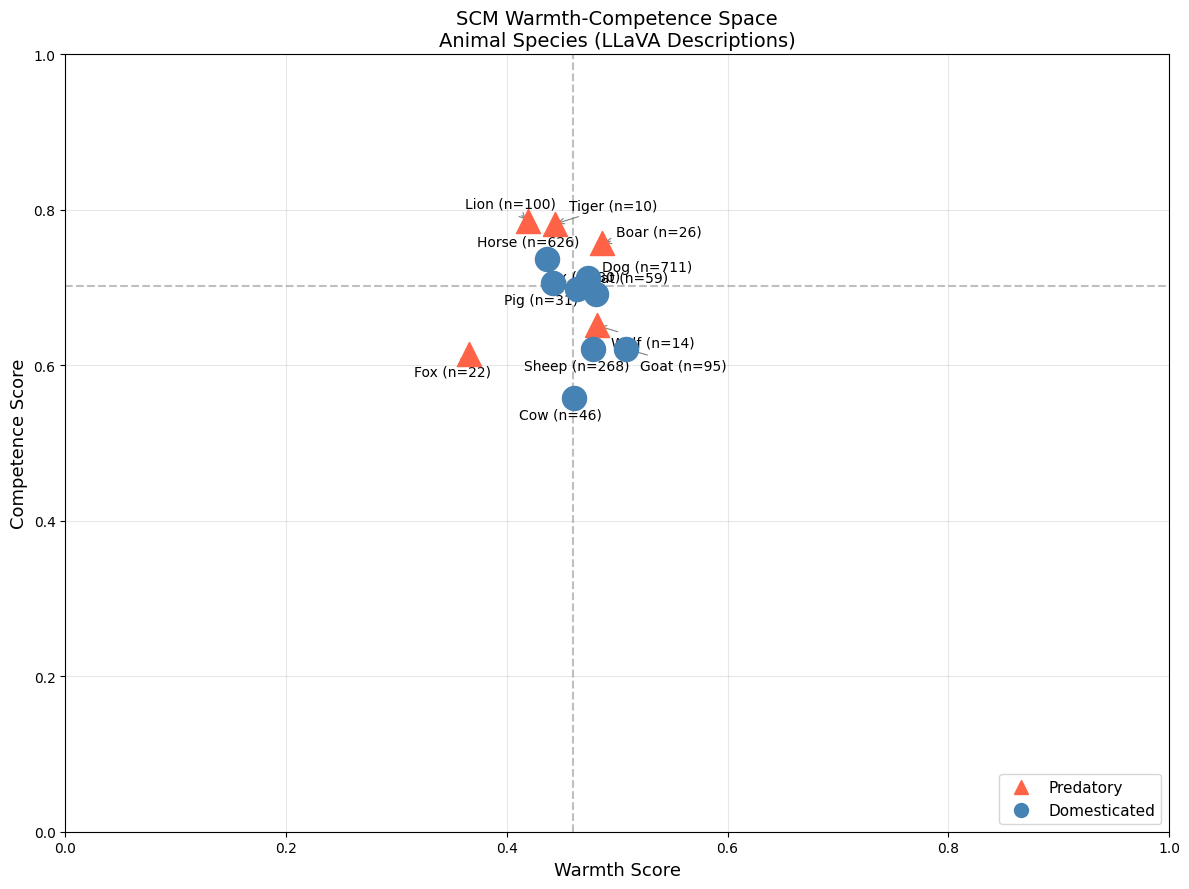

Plot saved!


In [24]:
fig, ax = plt.subplots(figsize=(12, 9))

pred_color = 'tomato'
dom_color = 'steelblue'

# Manual label offsets to avoid overlapping
label_offsets = {
    'Lion':  (-45, 10),
    'Tiger': (10, 10),
    'Boar':  (10, 5),
    'Wolf':  (10, -15),
    'Fox':   (-40, -15),
    'Dog':   (10, 5),
    'Horse': (-50, 10),
    'Sheep': (-50, -15),
    'Goat':  (10, -15),
    'Cow':   (-40, -15),
    'Ox':    (-35, 10),
    'Pig':   (-35, -15),
    'Cat':   (10, 5),
}

for name, df in pred_subcat_scores.items():
    warmth = df['warmth_score'].mean()
    competence = df['competence_score'].mean()
    n = len(df)
    ax.scatter(warmth, competence, c=pred_color, marker='^', s=300, zorder=5)
    ax.annotate(f'{name} (n={n})', (warmth, competence),
                textcoords="offset points", 
                xytext=label_offsets[name], fontsize=10,
                arrowprops=dict(arrowstyle='->', color='gray', lw=0.8))

for name, df in dom_subcat_scores.items():
    warmth = df['warmth_score'].mean()
    competence = df['competence_score'].mean()
    n = len(df)
    ax.scatter(warmth, competence, c=dom_color, marker='o', s=300, zorder=5)
    ax.annotate(f'{name} (n={n})', (warmth, competence),
                textcoords="offset points",
                xytext=label_offsets[name], fontsize=10,
                arrowprops=dict(arrowstyle='->', color='gray', lw=0.8))

# Quadrant lines
overall_animal = pd.concat(list(all_animal_scores.values()))
animal_warmth_mean = overall_animal['warmth_score'].mean()
animal_comp_mean = overall_animal['competence_score'].mean()

ax.axvline(x=animal_warmth_mean, color='gray', linestyle='--', alpha=0.5,
           label=f'Animal warmth mean ({animal_warmth_mean:.2f})')
ax.axhline(y=animal_comp_mean, color='gray', linestyle='--', alpha=0.5,
           label=f'Animal competence mean ({animal_comp_mean:.2f})')

import matplotlib.lines as mlines
pred_legend = mlines.Line2D([], [], color=pred_color, marker='^', linestyle='None',
                             markersize=10, label='Predatory')
dom_legend  = mlines.Line2D([], [], color=dom_color, marker='o', linestyle='None',
                             markersize=10, label='Domesticated')
ax.legend(handles=[pred_legend, dom_legend], fontsize=11, loc='lower right')

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xlabel('Warmth Score', fontsize=13)
ax.set_ylabel('Competence Score', fontsize=13)
ax.set_title('SCM Warmth-Competence Space\nAnimal Species (LLaVA Descriptions)', fontsize=14)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/home/agrupa-lab/agrupa/IE_capstones/Omar/outputs/animal_subcategory_scm.png',
            dpi=300, bbox_inches='tight')
plt.show()
print("Plot saved!")

In [25]:
from scipy.stats import kruskal

all_pred = pd.concat(list(pred_subcat_scores.values()))
all_dom = pd.concat(list(dom_subcat_scores.values()))

groups_warmth = [df['warmth_score'].dropna().values for df in all_animal_scores.values()]
groups_comp = [df['competence_score'].dropna().values for df in all_animal_scores.values()]

kw_warmth, p_warmth = kruskal(*groups_warmth)
kw_comp, p_comp = kruskal(*groups_comp)

print("=== Animal Species Differences ===")
print(f"\nKruskal-Wallis Warmth:     H={kw_warmth:.3f}, p={p_warmth:.4f}")
print(f"Kruskal-Wallis Competence: H={kw_comp:.3f}, p={p_comp:.4f}")

if p_warmth < 0.05:
    print("\nWarmth: SIGNIFICANT differences across animal species ✓")
else:
    print("\nWarmth: No significant differences across animal species")

if p_comp < 0.05:
    print("Competence: SIGNIFICANT differences across animal species ✓")
else:
    print("Competence: No significant differences across animal species")

=== Animal Species Differences ===

Kruskal-Wallis Warmth:     H=17.640, p=0.1271
Kruskal-Wallis Competence: H=87.867, p=0.0000

Warmth: No significant differences across animal species
Competence: SIGNIFICANT differences across animal species ✓


In [26]:
conn = sqlite3.connect(DB_PATH)

# Find artworks that have BOTH a horse tag AND an elite tag
horse_elite = pd.read_sql("""
    SELECT a.cat_no, a.titulo, a.autor
    FROM artwork a
    INNER JOIN artwork_tag t1 ON a.cat_no = t1.cat_no
    INNER JOIN artwork_tag t2 ON a.cat_no = t2.cat_no
    WHERE t1.tag_id = 178  -- Horse
    AND t2.tag_id IN (402, 403, 406, 407, 408, 409)  -- Elite tags
""", conn)

# Find artworks that have BOTH a horse tag AND a non-elite tag
horse_nonelite = pd.read_sql("""
    SELECT a.cat_no, a.titulo, a.autor
    FROM artwork a
    INNER JOIN artwork_tag t1 ON a.cat_no = t1.cat_no
    INNER JOIN artwork_tag t2 ON a.cat_no = t2.cat_no
    WHERE t1.tag_id = 178  -- Horse
    AND t2.tag_id IN (358, 359, 360, 361, 364, 369, 370, 371, 372, 373, 376, 377, 380)  -- Non-elite tags
""", conn)

conn.close()

print(f"Horse + Elite artworks: {len(horse_elite)}")
print(f"Horse + Non-Elite artworks: {len(horse_nonelite)}")
print("\nSample Horse + Elite:")
print(horse_elite.head())
print("\nSample Horse + Non-Elite:")
print(horse_nonelite.head())

Horse + Elite artworks: 133
Horse + Non-Elite artworks: 40

Sample Horse + Elite:
    cat_no                                  titulo  \
0  P000197                     Carlos II a caballo   
1  P000197                     Carlos II a caballo   
2  P000198  La reina Mariana de Neoburgo a caballo   
3  P000198  La reina Mariana de Neoburgo a caballo   
4  P000410      Carlos V en la batalla de Mühlberg   

                           autor  
0                 Giordano, Luca  
1                 Giordano, Luca  
2                 Giordano, Luca  
3                 Giordano, Luca  
4  Tiziano, Vecellio di Gregorio  

Sample Horse + Non-Elite:
    cat_no              titulo                           autor
0  P000030        La Primavera             Bassano (Taller de)
1  P000096              Cabaña         Cerquozzi, Michelangelo
2  P000794  La era o El Verano  Goya y Lucientes, Francisco de
3  P000875          Pescadores        Maella, Mariano Salvador
4  P001362            Caravana           

In [27]:
# Get scores for each context
horse_elite_scores = scores_df[scores_df['cat_no'].isin(horse_elite['cat_no'].unique())]
horse_nonelite_scores = scores_df[scores_df['cat_no'].isin(horse_nonelite['cat_no'].unique())]

print(f"Horse + Elite with scores: {len(horse_elite_scores)}")
print(f"Horse + Non-Elite with scores: {len(horse_nonelite_scores)}")

print("\n=== Horse in Elite Context ===")
print(f"Mean Warmth:     {horse_elite_scores['warmth_score'].mean():.3f}")
print(f"Mean Competence: {horse_elite_scores['competence_score'].mean():.3f}")

print("\n=== Horse in Non-Elite Context ===")
print(f"Mean Warmth:     {horse_nonelite_scores['warmth_score'].mean():.3f}")
print(f"Mean Competence: {horse_nonelite_scores['competence_score'].mean():.3f}")

print("\n=== Horse Overall (no context filter) ===")
horse_all = scores_df[scores_df['cat_no'].isin(
    artwork_tags[artwork_tags['tag_id'] == 178]['cat_no'].unique()
)]
print(f"Mean Warmth:     {horse_all['warmth_score'].mean():.3f}")
print(f"Mean Competence: {horse_all['competence_score'].mean():.3f}")

# Statistical test
t_warmth, p_warmth = stats.ttest_ind(
    horse_elite_scores['warmth_score'].dropna(),
    horse_nonelite_scores['warmth_score'].dropna()
)
t_comp, p_comp = stats.ttest_ind(
    horse_elite_scores['competence_score'].dropna(),
    horse_nonelite_scores['competence_score'].dropna()
)

print("\n=== Statistical Tests ===")
print(f"Warmth t-test:     t={t_warmth:.3f}, p={p_warmth:.4f}")
print(f"Competence t-test: t={t_comp:.3f}, p={p_comp:.4f}")

Horse + Elite with scores: 62
Horse + Non-Elite with scores: 35

=== Horse in Elite Context ===
Mean Warmth:     0.437
Mean Competence: 0.803

=== Horse in Non-Elite Context ===
Mean Warmth:     0.524
Mean Competence: 0.650

=== Horse Overall (no context filter) ===
Mean Warmth:     0.436
Mean Competence: 0.736

=== Statistical Tests ===
Warmth t-test:     t=-2.211, p=0.0295
Competence t-test: t=3.094, p=0.0026


In [28]:
# Extend to dogs as well
dog_elite = pd.read_sql("""
    SELECT DISTINCT a.cat_no FROM artwork a
    INNER JOIN artwork_tag t1 ON a.cat_no = t1.cat_no
    INNER JOIN artwork_tag t2 ON a.cat_no = t2.cat_no
    WHERE t1.tag_id = 217
    AND t2.tag_id IN (402, 403, 406, 407, 408, 409)
""", conn) if False else None

conn = sqlite3.connect(DB_PATH)
dog_elite = pd.read_sql("""
    SELECT DISTINCT a.cat_no FROM artwork a
    INNER JOIN artwork_tag t1 ON a.cat_no = t1.cat_no
    INNER JOIN artwork_tag t2 ON a.cat_no = t2.cat_no
    WHERE t1.tag_id = 217
    AND t2.tag_id IN (402, 403, 406, 407, 408, 409)
""", conn)

dog_nonelite = pd.read_sql("""
    SELECT DISTINCT a.cat_no FROM artwork a
    INNER JOIN artwork_tag t1 ON a.cat_no = t1.cat_no
    INNER JOIN artwork_tag t2 ON a.cat_no = t2.cat_no
    WHERE t1.tag_id = 217
    AND t2.tag_id IN (358, 359, 360, 361, 364, 369, 370, 371, 372, 373, 376, 377, 380)
""", conn)
conn.close()

dog_elite_scores = scores_df[scores_df['cat_no'].isin(dog_elite['cat_no'].unique())]
dog_nonelite_scores = scores_df[scores_df['cat_no'].isin(dog_nonelite['cat_no'].unique())]

print(f"Dog + Elite with scores: {len(dog_elite_scores)}")
print(f"Dog + Non-Elite with scores: {len(dog_nonelite_scores)}")

print("\n=== Dog in Elite Context ===")
print(f"Mean Warmth:     {dog_elite_scores['warmth_score'].mean():.3f}")
print(f"Mean Competence: {dog_elite_scores['competence_score'].mean():.3f}")

print("\n=== Dog in Non-Elite Context ===")
print(f"Mean Warmth:     {dog_nonelite_scores['warmth_score'].mean():.3f}")
print(f"Mean Competence: {dog_nonelite_scores['competence_score'].mean():.3f}")

Dog + Elite with scores: 50
Dog + Non-Elite with scores: 36

=== Dog in Elite Context ===
Mean Warmth:     0.386
Mean Competence: 0.665

=== Dog in Non-Elite Context ===
Mean Warmth:     0.505
Mean Competence: 0.556


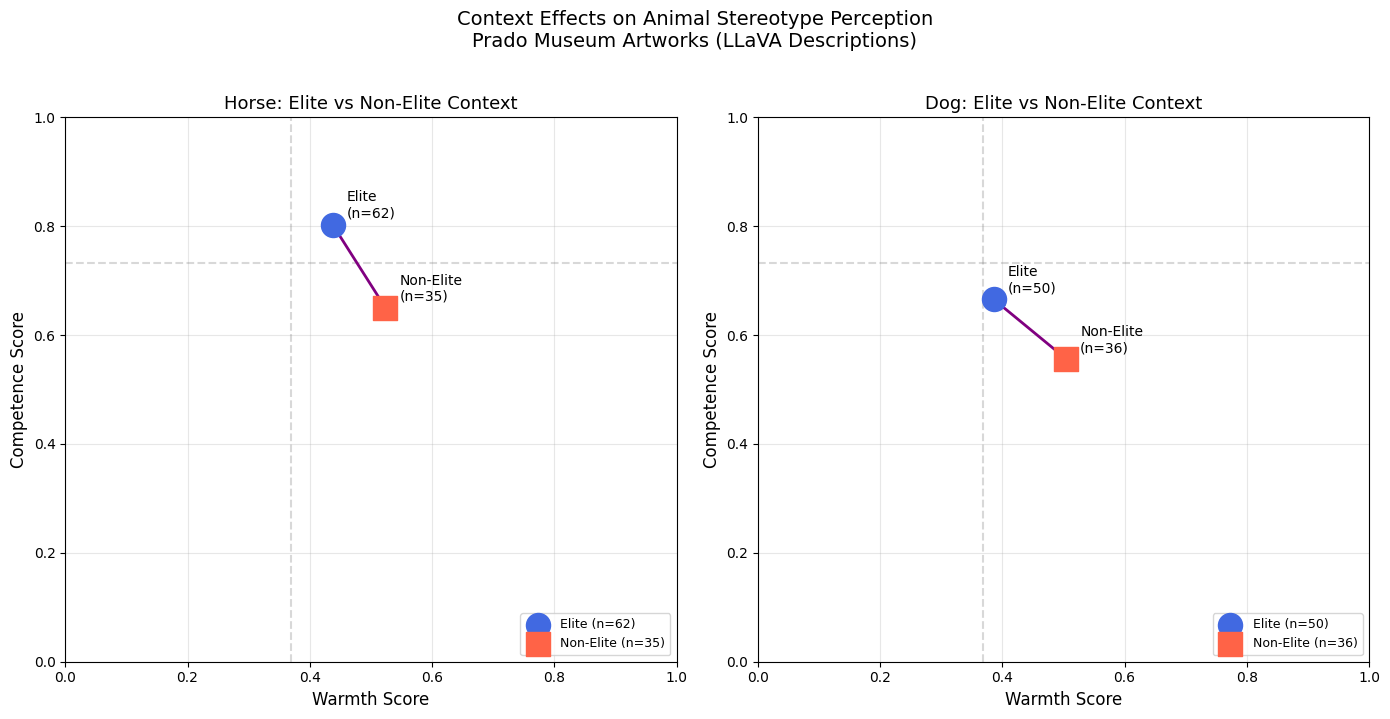

Plot saved!


In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

context_data = {
    'Horse': {
        'Elite':     (horse_elite_scores['warmth_score'].mean(), horse_elite_scores['competence_score'].mean(), len(horse_elite_scores)),
        'Non-Elite': (horse_nonelite_scores['warmth_score'].mean(), horse_nonelite_scores['competence_score'].mean(), len(horse_nonelite_scores)),
    },
    'Dog': {
        'Elite':     (dog_elite_scores['warmth_score'].mean(), dog_elite_scores['competence_score'].mean(), len(dog_elite_scores)),
        'Non-Elite': (dog_nonelite_scores['warmth_score'].mean(), dog_nonelite_scores['competence_score'].mean(), len(dog_nonelite_scores)),
    }
}

colors  = {'Elite': 'royalblue', 'Non-Elite': 'tomato'}
markers = {'Elite': 'o', 'Non-Elite': 's'}

for ax, (animal, contexts) in zip(axes, context_data.items()):
    for context, (warmth, competence, n) in contexts.items():
        ax.scatter(warmth, competence, c=colors[context], marker=markers[context],
                   s=300, zorder=5, label=f'{context} (n={n})')
        ax.annotate(f'{context}\n(n={n})', (warmth, competence),
                    textcoords="offset points", xytext=(10, 5), fontsize=10)

    # Arrow from Non-Elite to Elite
    ne_w, ne_c, _ = contexts['Non-Elite']
    el_w, el_c, _ = contexts['Elite']
    ax.annotate('', xy=(el_w, el_c), xytext=(ne_w, ne_c),
                arrowprops=dict(arrowstyle='->', color='purple', lw=2))

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel('Warmth Score', fontsize=12)
    ax.set_ylabel('Competence Score', fontsize=12)
    ax.set_title(f'{animal}: Elite vs Non-Elite Context', fontsize=13)
    ax.legend(fontsize=9, loc='lower right')
    ax.grid(True, alpha=0.3)
    ax.axvline(x=scores_df['warmth_score'].mean(), color='gray', linestyle='--', alpha=0.3)
    ax.axhline(y=scores_df['competence_score'].mean(), color='gray', linestyle='--', alpha=0.3)

plt.suptitle('Context Effects on Animal Stereotype Perception\nPrado Museum Artworks (LLaVA Descriptions)',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('/home/agrupa-lab/agrupa/IE_capstones/Omar/outputs/context_effects.png',
            dpi=300, bbox_inches='tight')
plt.show()
print("Plot saved!")

In [30]:
t_warmth_dog, p_warmth_dog = stats.ttest_ind(
    dog_elite_scores['warmth_score'].dropna(),
    dog_nonelite_scores['warmth_score'].dropna()
)
t_comp_dog, p_comp_dog = stats.ttest_ind(
    dog_elite_scores['competence_score'].dropna(),
    dog_nonelite_scores['competence_score'].dropna()
)

print("=== Context Effects Summary ===")
print(f"\nHorse:")
print(f"  Warmth:     Elite={horse_elite_scores['warmth_score'].mean():.3f} vs Non-Elite={horse_nonelite_scores['warmth_score'].mean():.3f} | p={p_warmth:.4f}")
print(f"  Competence: Elite={horse_elite_scores['competence_score'].mean():.3f} vs Non-Elite={horse_nonelite_scores['competence_score'].mean():.3f} | p={p_comp:.4f}")

print(f"\nDog:")
print(f"  Warmth:     Elite={dog_elite_scores['warmth_score'].mean():.3f} vs Non-Elite={dog_nonelite_scores['warmth_score'].mean():.3f} | p={p_warmth_dog:.4f}")
print(f"  Competence: Elite={dog_elite_scores['competence_score'].mean():.3f} vs Non-Elite={dog_nonelite_scores['competence_score'].mean():.3f} | p={p_comp_dog:.4f}")

=== Context Effects Summary ===

Horse:
  Warmth:     Elite=0.437 vs Non-Elite=0.524 | p=0.0295
  Competence: Elite=0.803 vs Non-Elite=0.650 | p=0.0026

Dog:
  Warmth:     Elite=0.386 vs Non-Elite=0.505 | p=0.0120
  Competence: Elite=0.665 vs Non-Elite=0.556 | p=0.0664


In [31]:
from scipy.stats import shapiro, levene, mannwhitneyu

print("=" * 60)
print("ASSUMPTION TESTS — H2a & H2b: Elite vs Laboring Figures")
print("=" * 60)

# Normality tests (Shapiro-Wilk on sample of 50)
stat_norm_elite_comp, p_norm_elite_comp = shapiro(
    elite_scores['competence_score'].dropna().sample(50, random_state=42))
stat_norm_nonelite_comp, p_norm_nonelite_comp = shapiro(
    nonelite_scores['competence_score'].dropna().sample(50, random_state=42))
stat_norm_elite_warm, p_norm_elite_warm = shapiro(
    elite_scores['warmth_score'].dropna().sample(50, random_state=42))
stat_norm_nonelite_warm, p_norm_nonelite_warm = shapiro(
    nonelite_scores['warmth_score'].dropna().sample(50, random_state=42))

print("\nNormality (Shapiro-Wilk):")
print(f"  Elite Competence:     W={stat_norm_elite_comp:.3f}, p={p_norm_elite_comp:.4f}")
print(f"  Laboring Competence:  W={stat_norm_nonelite_comp:.3f}, p={p_norm_nonelite_comp:.4f}")
print(f"  Elite Warmth:         W={stat_norm_elite_warm:.3f}, p={p_norm_elite_warm:.4f}")
print(f"  Laboring Warmth:      W={stat_norm_nonelite_warm:.3f}, p={p_norm_nonelite_warm:.4f}")

# Homoscedasticity tests (Levene)
stat_lev_comp, p_lev_comp = levene(
    elite_scores['competence_score'].dropna(),
    nonelite_scores['competence_score'].dropna())
stat_lev_warm, p_lev_warm = levene(
    elite_scores['warmth_score'].dropna(),
    nonelite_scores['warmth_score'].dropna())

print("\nHomoscedasticity (Levene's test):")
print(f"  Competence: F={stat_lev_comp:.3f}, p={p_lev_comp:.4f}")
print(f"  Warmth:     F={stat_lev_warm:.3f}, p={p_lev_warm:.4f}")

# Interpretation
print("\nInterpretation:")
for name, p_norm1, p_norm2, p_lev in [
    ("Competence", p_norm_elite_comp, p_norm_nonelite_comp, p_lev_comp),
    ("Warmth", p_norm_elite_warm, p_norm_nonelite_warm, p_lev_warm)
]:
    normality = "VIOLATED" if p_norm1 < 0.05 or p_norm2 < 0.05 else "MET"
    homoscedasticity = "VIOLATED" if p_lev < 0.05 else "MET"
    print(f"  {name}: Normality {normality}, Homoscedasticity {homoscedasticity}")

ASSUMPTION TESTS — H2a & H2b: Elite vs Laboring Figures

Normality (Shapiro-Wilk):
  Elite Competence:     W=0.787, p=0.0000
  Laboring Competence:  W=0.962, p=0.1048
  Elite Warmth:         W=0.939, p=0.0118
  Laboring Warmth:      W=0.928, p=0.0048

Homoscedasticity (Levene's test):
  Competence: F=5.745, p=0.0167
  Warmth:     F=7.778, p=0.0054

Interpretation:
  Competence: Normality VIOLATED, Homoscedasticity VIOLATED
  Warmth: Normality VIOLATED, Homoscedasticity VIOLATED


In [32]:
print("=" * 60)
print("ASSUMPTION TESTS — H3a & H3b: Predatory vs Domesticated")
print("=" * 60)

stat_norm_pred_comp, p_norm_pred_comp = shapiro(
    predatory_scores['competence_score'].dropna().sample(50, random_state=42))
stat_norm_dom_comp, p_norm_dom_comp = shapiro(
    domesticated_scores['competence_score'].dropna().sample(50, random_state=42))
stat_norm_pred_warm, p_norm_pred_warm = shapiro(
    predatory_scores['warmth_score'].dropna().sample(50, random_state=42))
stat_norm_dom_warm, p_norm_dom_warm = shapiro(
    domesticated_scores['warmth_score'].dropna().sample(50, random_state=42))

print("\nNormality (Shapiro-Wilk):")
print(f"  Predatory Competence:    W={stat_norm_pred_comp:.3f}, p={p_norm_pred_comp:.4f}")
print(f"  Domesticated Competence: W={stat_norm_dom_comp:.3f}, p={p_norm_dom_comp:.4f}")
print(f"  Predatory Warmth:        W={stat_norm_pred_warm:.3f}, p={p_norm_pred_warm:.4f}")
print(f"  Domesticated Warmth:     W={stat_norm_dom_warm:.3f}, p={p_norm_dom_warm:.4f}")

stat_lev_comp2, p_lev_comp2 = levene(
    predatory_scores['competence_score'].dropna(),
    domesticated_scores['competence_score'].dropna())
stat_lev_warm2, p_lev_warm2 = levene(
    predatory_scores['warmth_score'].dropna(),
    domesticated_scores['warmth_score'].dropna())

print("\nHomoscedasticity (Levene's test):")
print(f"  Competence: F={stat_lev_comp2:.3f}, p={p_lev_comp2:.4f}")
print(f"  Warmth:     F={stat_lev_warm2:.3f}, p={p_lev_warm2:.4f}")

print("\nInterpretation:")
for name, p_norm1, p_norm2, p_lev in [
    ("Competence", p_norm_pred_comp, p_norm_dom_comp, p_lev_comp2),
    ("Warmth", p_norm_pred_warm, p_norm_dom_warm, p_lev_warm2)
]:
    normality = "VIOLATED" if p_norm1 < 0.05 or p_norm2 < 0.05 else "MET"
    homoscedasticity = "VIOLATED" if p_lev < 0.05 else "MET"
    print(f"  {name}: Normality {normality}, Homoscedasticity {homoscedasticity}")

ASSUMPTION TESTS — H3a & H3b: Predatory vs Domesticated

Normality (Shapiro-Wilk):
  Predatory Competence:    W=0.942, p=0.0169
  Domesticated Competence: W=0.910, p=0.0011
  Predatory Warmth:        W=0.974, p=0.3305
  Domesticated Warmth:     W=0.959, p=0.0805

Homoscedasticity (Levene's test):
  Competence: F=1.680, p=0.1951
  Warmth:     F=0.661, p=0.4164

Interpretation:
  Competence: Normality VIOLATED, Homoscedasticity MET
  Warmth: Normality MET, Homoscedasticity MET


In [34]:
from scipy.stats import mannwhitneyu

# H2a — Elite vs Laboring Competence
u_h2a, p_h2a = mannwhitneyu(
    elite_scores['competence_score'].dropna(),
    nonelite_scores['competence_score'].dropna(),
    alternative='greater'
)
# H2b — Laboring vs Elite Warmth
u_h2b, p_h2b = mannwhitneyu(
    nonelite_scores['warmth_score'].dropna(),
    elite_scores['warmth_score'].dropna(),
    alternative='greater'
)
# H3a — Predatory vs Domesticated Competence
u_h3a, p_h3a = mannwhitneyu(
    predatory_scores['competence_score'].dropna(),
    domesticated_scores['competence_score'].dropna(),
    alternative='greater'
)

print(f"H2a Competence: U={u_h2a:.0f}, p={p_h2a:.4f}")
print(f"H2b Warmth:     U={u_h2b:.0f}, p={p_h2b:.4f}")
print(f"H3a Competence: U={u_h3a:.0f}, p={p_h3a:.4f}")

H2a Competence: U=116172, p=0.0000
H2b Warmth:     U=106091, p=0.0000
H3a Competence: U=117226, p=0.0134


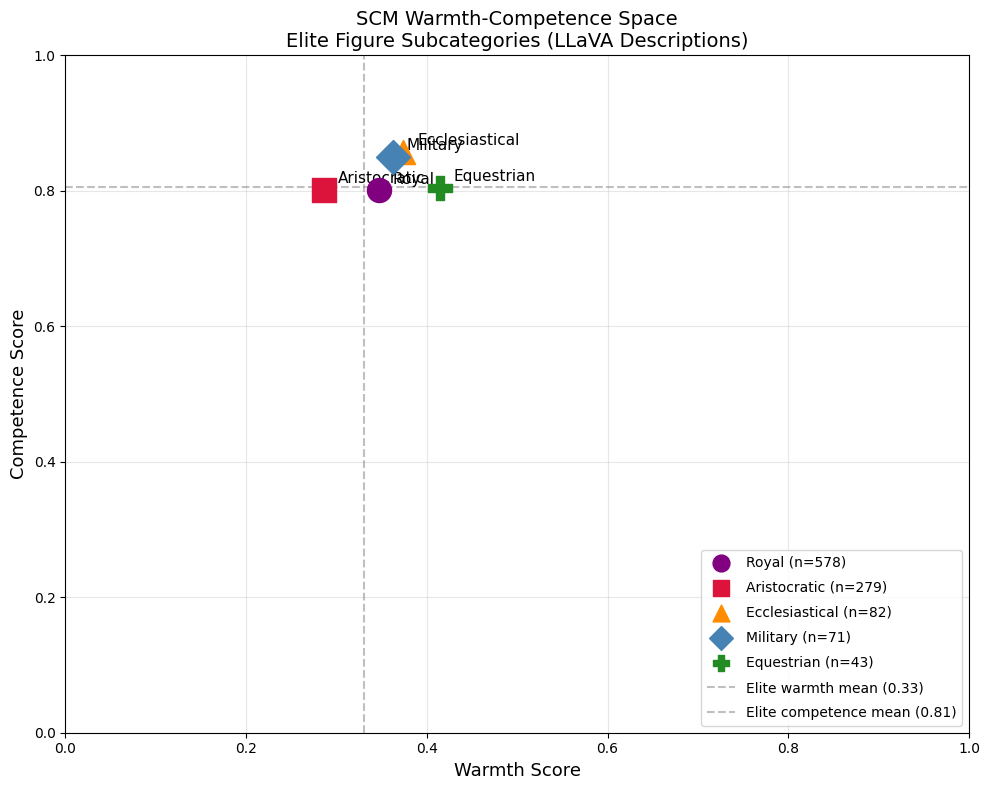

Plot saved!


In [35]:
fig, ax = plt.subplots(figsize=(10, 8))

colors = ['purple', 'crimson', 'darkorange', 'steelblue', 'forestgreen']
markers = ['o', 's', '^', 'D', 'P']

for (name, df), color, marker in zip(subcat_scores.items(), colors, markers):
    warmth = df['warmth_score'].mean()
    competence = df['competence_score'].mean()
    n = len(df)
    ax.scatter(warmth, competence, c=color, marker=marker, 
               s=300, zorder=5, label=f'{name} (n={n})')
    ax.annotate(name, (warmth, competence),
                textcoords="offset points", xytext=(10, 5), fontsize=11)

elite_warmth_mean = elite_scores['warmth_score'].mean()
elite_comp_mean = elite_scores['competence_score'].mean()

ax.axvline(x=elite_warmth_mean, color='gray', linestyle='--', alpha=0.5,
           label=f'Elite warmth mean ({elite_warmth_mean:.2f})')
ax.axhline(y=elite_comp_mean, color='gray', linestyle='--', alpha=0.5,
           label=f'Elite competence mean ({elite_comp_mean:.2f})')

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xlabel('Warmth Score', fontsize=13)
ax.set_ylabel('Competence Score', fontsize=13)
ax.set_title('SCM Warmth-Competence Space\nElite Figure Subcategories (LLaVA Descriptions)', fontsize=14)

ax.legend(fontsize=10, loc='lower right', markerscale=0.7, labelspacing=0.8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/home/agrupa-lab/agrupa/IE_capstones/Omar/outputs/elite_subcategory_scm.png', 
            dpi=300, bbox_inches='tight')
plt.show()
print("Plot saved!")

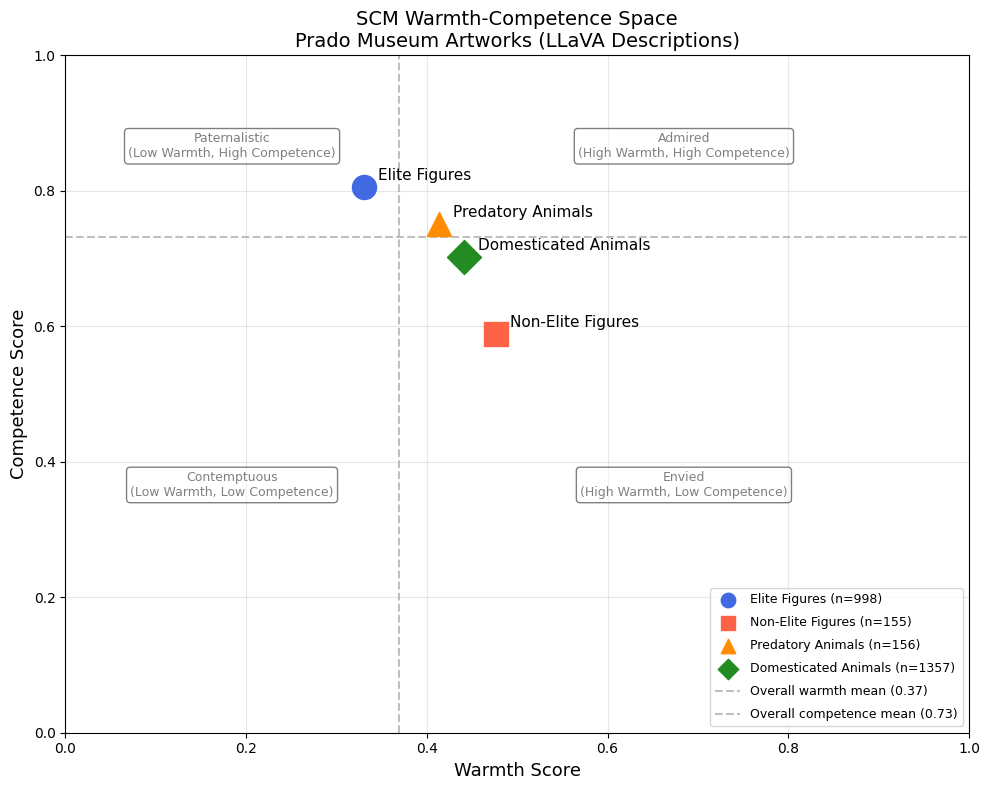

Plot saved!


In [36]:
fig, ax = plt.subplots(1, 1, figsize=(10, 8))

groups = {
    'Elite Figures':        (elite_scores['warmth_score'].mean(), elite_scores['competence_score'].mean(), 'royalblue', 'o', len(elite_scores)),
    'Non-Elite Figures':    (nonelite_scores['warmth_score'].mean(), nonelite_scores['competence_score'].mean(), 'tomato', 's', len(nonelite_scores)),
    'Predatory Animals':    (predatory_scores['warmth_score'].mean(), predatory_scores['competence_score'].mean(), 'darkorange', '^', len(predatory_scores)),
    'Domesticated Animals': (domesticated_scores['warmth_score'].mean(), domesticated_scores['competence_score'].mean(), 'forestgreen', 'D', len(domesticated_scores)),
}

for name, (warmth, competence, color, marker, n) in groups.items():
    ax.scatter(warmth, competence, c=color, marker=marker, s=300, zorder=5, label=f'{name} (n={n})')
    ax.annotate(name, (warmth, competence), textcoords="offset points", xytext=(10, 5), fontsize=11)

# Quadrant lines at overall dataset means
overall_warmth_mean = scores_df['warmth_score'].mean()
overall_comp_mean = scores_df['competence_score'].mean()

ax.axvline(x=overall_warmth_mean, color='gray', linestyle='--', alpha=0.5,
           label=f'Overall warmth mean ({overall_warmth_mean:.2f})')
ax.axhline(y=overall_comp_mean, color='gray', linestyle='--', alpha=0.5,
           label=f'Overall competence mean ({overall_comp_mean:.2f})')

# Quadrant labels positioned at center of each quadrant based on means
mid_w_left  = overall_warmth_mean / 2
mid_w_right = overall_warmth_mean + (1 - overall_warmth_mean) / 2
mid_c_top   = overall_comp_mean + (1 - overall_comp_mean) / 2
mid_c_bot   = overall_comp_mean / 2

ax.text(mid_w_left, mid_c_top, 'Paternalistic\n(Low Warmth, High Competence)',
        fontsize=9, ha='center', va='center', color='gray',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.5))

ax.text(mid_w_right, mid_c_top, 'Admired\n(High Warmth, High Competence)',
        fontsize=9, ha='center', va='center', color='gray',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.5))

ax.text(mid_w_left, mid_c_bot, 'Contemptuous\n(Low Warmth, Low Competence)',
        fontsize=9, ha='center', va='center', color='gray',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.5))

ax.text(mid_w_right, mid_c_bot, 'Envied\n(High Warmth, Low Competence)',
        fontsize=9, ha='center', va='center', color='gray',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.5))

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xlabel('Warmth Score', fontsize=13)
ax.set_ylabel('Competence Score', fontsize=13)
ax.set_title('SCM Warmth-Competence Space\nPrado Museum Artworks (LLaVA Descriptions)', fontsize=14)

ax.legend(fontsize=9, loc='lower right', markerscale=0.6, labelspacing=0.8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/home/agrupa-lab/agrupa/IE_capstones/Omar/outputs/scm_quadrant_means.png',
            dpi=300, bbox_inches='tight')
plt.show()

print("Plot saved!")